Here we interpolate the beam to the same resolution as the sky (lmax=256). We compare healpix and mwss, only at the North Pole with no horizon.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/data/"
)

## Simulation cases

Everything at North Pole with no mountains.

Test NONE: No interpolation \
Test MWSS: MWSS interpolation \
Test HEALPIX: Healpix interpolation

In [20]:
tests = {
    "none": "no interpolation",
    "mwss": "MWSS interpolation",
    "healpix": "healpix interpolation",
}
# raul only has one result (the healpix case)
sim_res_chb = {}

## Raul's simulations

In [21]:
import h5py


def read_hdf5_convolution(path_file, print_key=False):
    with h5py.File(path_file, "r") as hf:
        if print_key:
            print([key for key in hf.keys()])

        hfX = hf.get("lst")
        lst = np.array(hfX)
        hfX = hf.get("freq")
        freq = np.array(hfX)
        hfX = hf.get("ant_temp")
        ant_temp = np.array(hfX)

    return lst, freq, ant_temp

# north pole, no mountains
path = Path("20260220_for_christian/antenna_temperature_20260220_test2.hdf5")
lst, _freqs, ant_temp_r = read_hdf5_convolution(DATA_DIR / path)
assert np.allclose(freqs, _freqs)
sim_res_raul = ant_temp_r

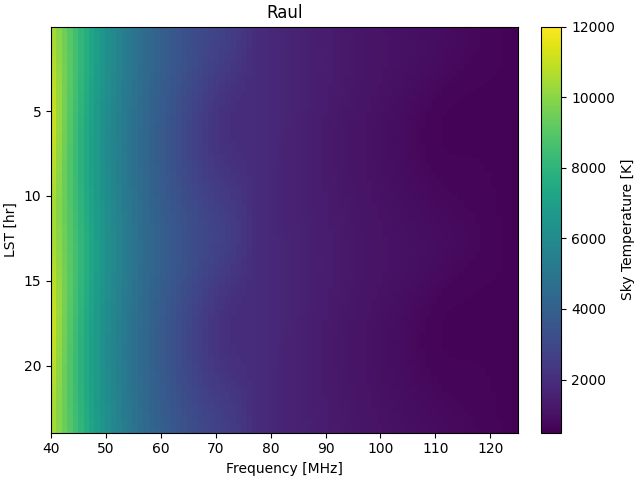

In [23]:
wfall_kwargs = {
    "extent": [freqs[0], freqs[-1], lst[-1], lst[0]],  # not exact for np
    "interpolation": "none",
    "aspect": "auto",
    "vmin": 500,
    "vmax": 12000,
}

fig, ax = plt.subplots(
    nrows=1, ncols=1, sharex=True, sharey=True, constrained_layout=True,
)
im = ax.imshow(v, **wfall_kwargs)
ax.set_title("Raul")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("LST [hr]")
fig.colorbar(im, ax=ax, label="Sky Temperature [K]")
plt.show()

## MISTSIM

In [24]:
import jax

jax.config.update('jax_enable_x64', True)

In [40]:
import astropy.units as u
import croissant as cro
import healpy as hp
import s2fft
from astropy.coordinates import EarthLocation
from astropy.time import Time

import mistsim as ms

## Sky model

In [26]:
d = np.load(DATA_DIR / "haslam_galactic.npz")
NSIDE = d["nside"]
haslam = d["m"]
freqs = d["freqs"]

SIM_LMAX = 2 * NSIDE
print(f"{NSIDE=}, {SIM_LMAX=}")

sky_model = ms.Sky(haslam, freqs, sampling="healpix", coord="galactic")

NSIDE=array(128), SIM_LMAX=np.int64(256)


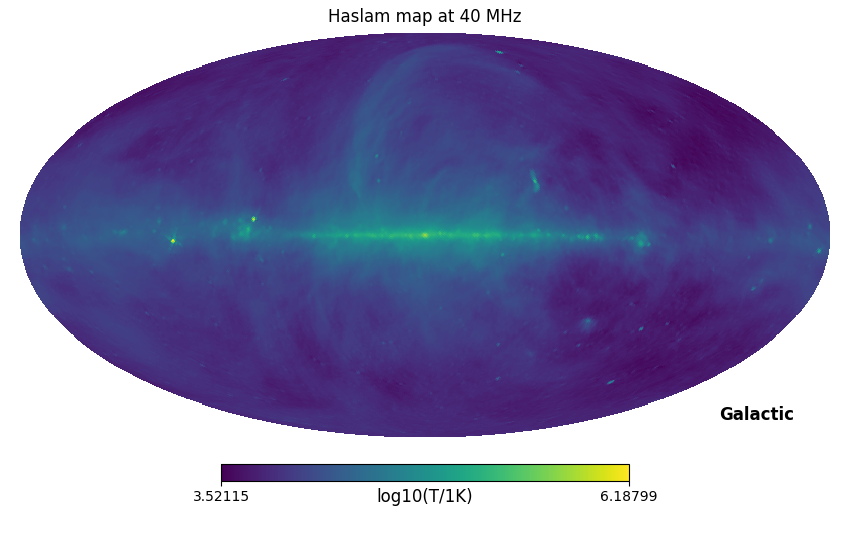

In [27]:
hp.mollview(
    np.log10(sky_model.data[0]),
    coord="G",
    title=f"Haslam map at {freqs[0]:.0f} MHz",
    cbar=True,
    unit="log10(T/1K)",
)
plt.show()

## Beam model

In [29]:
d = np.load(DATA_DIR / "beam.npz")

# check freqs match
assert np.allclose(d["freqs"], freqs)
phi = d["phi"]
theta = d["theta"]
gain = d["gain"]

beams = {}
# not interpolated
beams["none"] = ms.Beam(gain, freqs, sampling="mwss", horizon=None)

In [56]:
from scipy.interpolate import RectSphereBivariateSpline

# interp theta/phi: radians without poles
theta_i = np.deg2rad(theta[1:-1])
phi_i = np.deg2rad(phi)
gain_i = gain[:, 1:-1, :]
# pole values
gain_np = gain[:, 0, 0]
gain_sp = gain[:, -1, 0]

splines = [
    RectSphereBivariateSpline(
        theta_i,
        phi_i,
        gain_i[f],
        pole_continuity=True,
        pole_values=(gain_np[f], gain_sp[f]),
    )
    for f in range(len(gain))
]

# mwss
mwss_th = cro.utils.generate_theta(lmax=SIM_LMAX, sampling="mwss")
mwss_ph = cro.utils.generate_phi(lmax=SIM_LMAX, sampling="mwss")
mwss_gain = np.array([sp(mwss_th, mwss_ph, grid=True) for sp in splines])
beams["mwss"] = ms.Beam(mwss_gain, freqs, sampling="mwss", horizon=None)

# healpix
hp_th = cro.utils.generate_theta(sampling="healpix", nside=NSIDE)
hp_ph = cro.utils.generate_phi(sampling="healpix", nside=NSIDE)
hp_gain = np.array([sp(hp_th, hp_ph, grid=False) for sp in splines])
beams["healpix"] = ms.Beam(hp_gain, freqs, sampling="healpix", horizon=None)

print(gain.shape, mwss_gain.shape, hp_gain.shape)

(86, 181, 360) (86, 258, 514) (86, 196608)


## Simulator

In [57]:
# define observation time and location

# north pole
np_loc = EarthLocation.from_geodetic(0, 90, height=0)
print(np_loc)


def lst_to_time(lst_arr, t0):
    """
    Convert array of LST to array of astropy Time objects
    for use with croissant

    Parameters
    ----------
    lst_arr : array_like
        List of LST in hrs
    t0 : Time
        Reference time.
    """
    lst_ref = t0.sidereal_time("mean").hour
    delta = (lst_arr - lst_ref) /24 * u.sday
    times = t0 + delta
    return times

t0 = Time("2022-07-17 00:00", location=np_loc)
times = lst_to_time(lst, t0)

(3.9186209248144716e-10, 0.0, 6356752.314245179) m


In [62]:
sims = {}

for k in tests:
    print(f"Set up simulation {k}")
    beam = beams[k]
    times_jd = times.jd
    lon = np_loc.lon.deg
    lat = np_loc.lat.deg
    alt = np_loc.height.value\
    # set lmax
    if k == "none":
        lmax = 179
    else:
        lmax = SIM_LMAX
    sim = ms.Simulator(
        beam,
        sky_model,
        times_jd,
        freqs,
        lon,
        lat,
        alt=alt,
        lmax=lmax,
        Tgnd=0,
    )
    sims[k] = sim

Set up simulation none
Set up simulation mwss
Set up simulation healpix


In [63]:
tants = {}
for k, sim in sims.items():
    print(f"Run simulation {k}")
    tant = sim.sim()
    tants[k] = tant
    fgnd = sim.beam.compute_fgnd()
    tsky = cro.simulator.correct_ground_loss(tant, fgnd, 0)  # Tgnd=0
    sim_res_chb[k] = tsky

Run simulation none
Run simulation mwss
Run simulation healpix


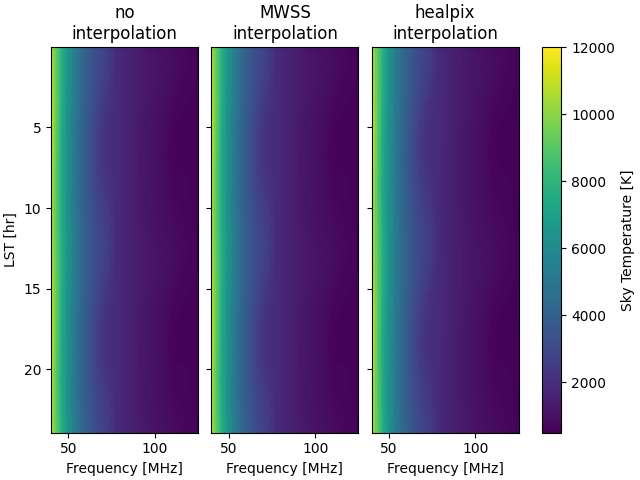

In [103]:
fig, axs = plt.subplots(
    nrows=1, ncols=3, sharex=True, sharey=True, constrained_layout=True,
)
for ax, k in zip(axs, sim_res_chb.keys()):
    v = sim_res_chb[k]
    im = ax.imshow(v, **wfall_kwargs)
    ax.set_title("\n".join(tests[k].split(" ")))
    ax.set_xlabel("Frequency [MHz]")
axs[0].set_ylabel("LST [hr]")
fig.colorbar(im, ax=axs, label="Sky Temperature [K]")
plt.show()

In [108]:
np.rad2deg(np.diff(mwss_th)[0])

np.float64(0.7003891050583657)

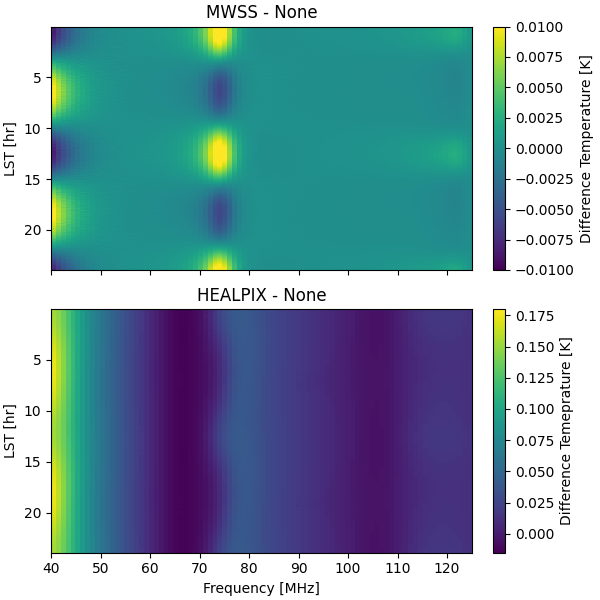

In [105]:
interp_kwargs = diff_kwargs.copy()

fig, axs = plt.subplots(
    figsize=(6, 6),
    nrows=2,
    ncols=1,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
interp_kwargs["vmin"] = -0.01
interp_kwargs["vmax"] = 0.01
im = axs[0].imshow(sim_res_chb["mwss"] - sim_res_chb["none"], **interp_kwargs)
axs[0].set_title("MWSS - None")
fig.colorbar(im, ax=axs[0], label="Difference Temperature [K]")
interp_kwargs["vmin"] = -0.015
interp_kwargs["vmax"] = 0.18
im = axs[1].imshow(sim_res_chb["healpix"] - sim_res_chb["none"], **interp_kwargs)
axs[1].set_title("HEALPIX - None")
fig.colorbar(im, ax=axs[1], label="Difference Temeprature [K]")
axs[1].set_xlabel("Frequency [MHz]")
plt.setp(axs, ylabel="LST [hr]")
plt.show()

## Save results

In [75]:
SAVE = True
if SAVE:
    np.savez(
        "comparison_beam_interp.npz",
        **sim_res_chb,
        sky_map=sky_model.data,
        beam_data=beams["none"].data,
        beam_mwss=beams["mwss"].data,
        beam_hp=beams["healpix"].data,
        freqs=freqs,
        lst=lst,
        tests=tests,
    )

## Compare Raul's sim with MISTSIM

-6.179701308534277 27.773566828895127
-6.171890178411559 27.778902799260322
-6.333393298711599 27.619487266279975


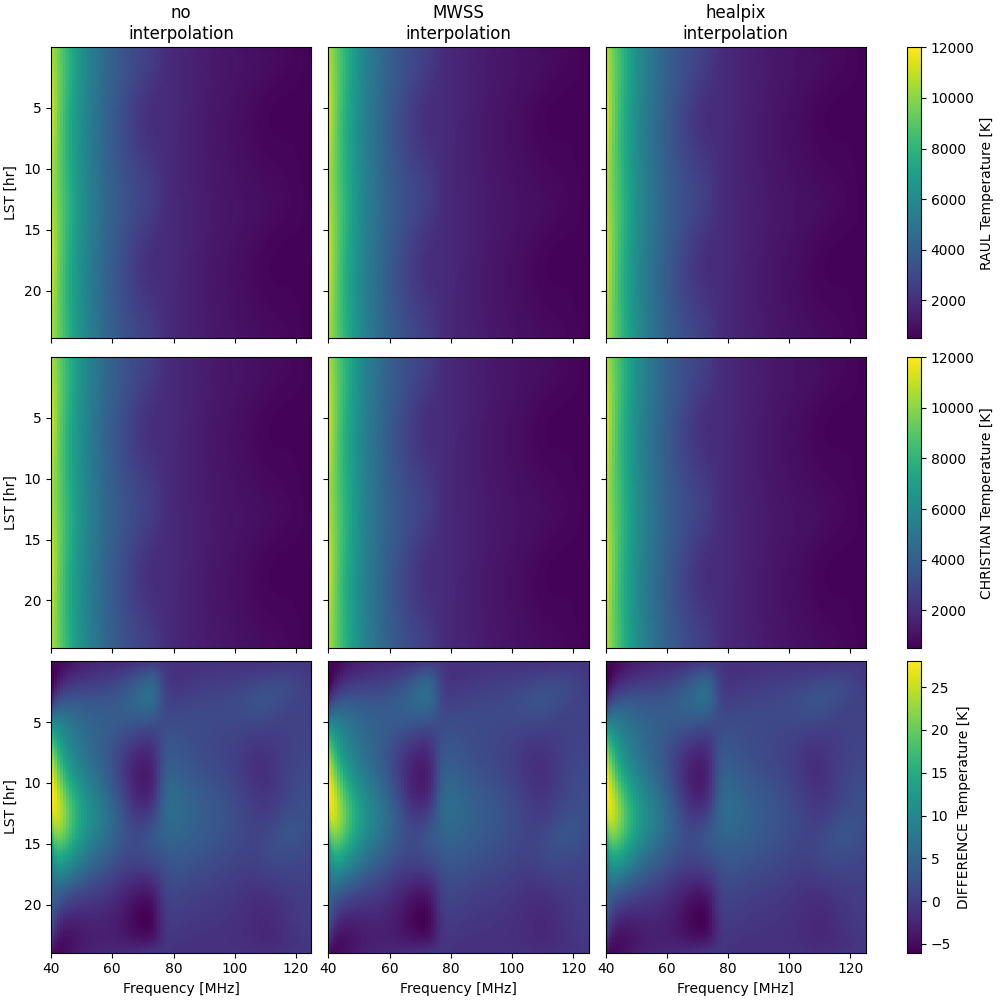

In [83]:
diff_kwargs = wfall_kwargs.copy()
diff_kwargs["vmin"] = -6
diff_kwargs["vmax"] = 28

fig, axs = plt.subplots(
    figsize=(10, 10),
    nrows=3,
    ncols=3,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for i, k in enumerate(sim_res_chb.keys()):
    chb_sim = sim_res_chb[k]
    diff = sim_res_raul - chb_sim
    print(np.min(diff), np.max(diff))
    imr = axs[0, i].imshow(sim_res_raul, **wfall_kwargs)
    imc = axs[1, i].imshow(chb_sim, **wfall_kwargs)
    imd = axs[2, i].imshow(diff, **diff_kwargs)
    axs[0, i].set_title("\n".join(tests[k].split(" ")))
    axs[2, i].set_xlabel("Frequency [MHz]")

fig.colorbar(imr, ax=axs[0], label="RAUL Temperature [K]")
fig.colorbar(imc, ax=axs[1], label="CHRISTIAN Temperature [K]")
fig.colorbar(imd, ax=axs[2], label="DIFFERENCE Temperature [K]")
plt.setp(axs[:, 0], ylabel="LST [hr]")

plt.show()